<a href="https://colab.research.google.com/github/MONISHKA1607/Accelerated_Data_Science_UCS547/blob/main/Assignment_6_RAPIDS_cuML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q kagglehub

!pip install -q cudf-cu12 cuml-cu12 \
    --extra-index-url=https://pypi.nvidia.com

!pip install -q cupy-cuda12x

!pip install -q xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import cupy as cp
import cudf

from cuml.model_selection import train_test_split
from cuml.ensemble import RandomForestClassifier
from cuml.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier as SkRF
from sklearn.metrics import accuracy_score as sk_accuracy

from xgboost import XGBClassifier

print("Libraries Loaded")

Libraries Loaded


QUESTION 1
Using the Adult Census Income Dataset (UCI Machine Learning Repository), design andimplement a complete machine learning pipeline to analyze and demonstrate GPU-acceleratedbinning and model training.
• Load and Preprocess the Dataset• Identify Feature Typeso Classify features as Continuous, Discrete, Categorical, or Binary.o Indicate which features are eligible for histogram binning on the GPU.• Demonstrate GPU-Based Histogram Binningo Use cuDF and CuPy to compute histograms for continuous features.o Compare results with CPU-based NumPy histograms and visualize them.• Perform Quantile Binning on the GPUo Compute quantiles and assign bin labels using GPU libraries.o Display bin edges and illustrate balanced data distribution.• Train and Compare CPU and GPU Models Performance• Implement the same experiment using XGBoost with tree_method='gpu_hist' andcompare the results with cuML.

In [3]:
adult_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

columns = [
    "age","workclass","fnlwgt","education",
    "education_num","marital_status",
    "occupation","relationship","race",
    "sex","capital_gain","capital_loss",
    "hours_per_week","native_country","income"
]

df = pd.read_csv(
    adult_url,
    names=columns,
    sep=", ",
    engine="python"
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
print(df.info())

print("\nShape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
None

Shape: (32561, 15)


In [5]:
continuous_features = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week"
]

categorical_features = [
    "workclass",
    "education",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native_country"
]

target = "income"

print("Continuous Features:")
print(continuous_features)

print("\nCategorical Features:")
print(categorical_features)

Continuous Features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical Features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in categorical_features + [target]:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0


In [8]:
gdf = cudf.from_pandas(df)

gdf.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0


In [9]:
gpu_histograms = {}

for col in continuous_features:

    gpu_array = cp.asarray(gdf[col])

    hist, bins = cp.histogram(
        gpu_array,
        bins=10
    )

    gpu_histograms[col] = (hist, bins)

    print(f"\nFeature: {col}")

    print("Histogram:")
    print(hist)

    print("Bins:")
    print(bins)


Feature: age
Histogram:
[5570 5890 6048 6163 3967 2591 1595  496  174   67]
Bins:
[17.  24.3 31.6 38.9 46.2 53.5 60.8 68.1 75.4 82.7 90. ]

Feature: fnlwgt
Histogram:
[13117 15327  3498   477   102    20    10     5     2     3]
Bins:
[  12285.  159527.  306769.  454011.  601253.  748495.  895737. 1042979.
 1190221. 1337463. 1484705.]

Feature: education_num
Histogram:
[  219   333  1160   933  1608 10501  8673  1067  7078   989]
Bins:
[ 1.   2.5  4.   5.5  7.   8.5 10.  11.5 13.  14.5 16. ]

Feature: capital_gain
Histogram:
[31791   517    87     5     2     0     0     0     0   159]
Bins:
[    0.   9999.9 19999.8 29999.7 39999.6 49999.5 59999.4 69999.3 79999.2
 89999.1 99999. ]

Feature: capital_loss
Histogram:
[31053    17    21   461   779   207    14     0     6     3]
Bins:
[   0.   435.6  871.2 1306.8 1742.4 2178.  2613.6 3049.2 3484.8 3920.4
 4356. ]

Feature: hours_per_week
Histogram:
[  736  2192  2317 17735  3119  3877  1796   448   202   139]
Bins:
[ 1.  10.8 20.6 30.4 40

In [10]:
cpu_histograms = {}

for col in continuous_features:

    hist, bins = np.histogram(
        df[col],
        bins=10
    )

    cpu_histograms[col] = (hist, bins)

    print(f"\nFeature: {col}")

    print("Histogram:")
    print(hist)

    print("Bins:")
    print(bins)


Feature: age
Histogram:
[5570 5890 6048 6163 3967 2591 1595  496  174   67]
Bins:
[17.  24.3 31.6 38.9 46.2 53.5 60.8 68.1 75.4 82.7 90. ]

Feature: fnlwgt
Histogram:
[13117 15327  3498   477   102    20    10     5     2     3]
Bins:
[  12285.  159527.  306769.  454011.  601253.  748495.  895737. 1042979.
 1190221. 1337463. 1484705.]

Feature: education_num
Histogram:
[  219   333  1160   933  1608 10501  8673  1067  7078   989]
Bins:
[ 1.   2.5  4.   5.5  7.   8.5 10.  11.5 13.  14.5 16. ]

Feature: capital_gain
Histogram:
[31791   517    87     5     2     0     0     0     0   159]
Bins:
[    0.   9999.9 19999.8 29999.7 39999.6 49999.5 59999.4 69999.3 79999.2
 89999.1 99999. ]

Feature: capital_loss
Histogram:
[31053    17    21   461   779   207    14     0     6     3]
Bins:
[   0.   435.6  871.2 1306.8 1742.4 2178.  2613.6 3049.2 3484.8 3920.4
 4356. ]

Feature: hours_per_week
Histogram:
[  736  2192  2317 17735  3119  3877  1796   448   202   139]
Bins:
[ 1.  10.8 20.6 30.4 40

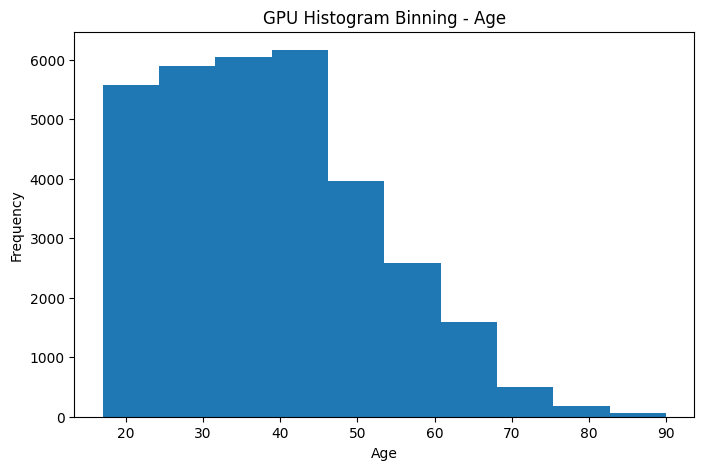

In [11]:
feature = "age"

gpu_hist = cp.asnumpy(gpu_histograms[feature][0])
gpu_bins = cp.asnumpy(gpu_histograms[feature][1])

plt.figure(figsize=(8,5))

plt.hist(
    df[feature],
    bins=gpu_bins
)

plt.title("GPU Histogram Binning - Age")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [12]:
feature = "age"

gpu_array = cp.asarray(gdf[feature])

quantiles = cp.percentile(
    gpu_array,
    [0,25,50,75,100]
)

print("Quantile Bin Edges:")

print(quantiles)

Quantile Bin Edges:
[17. 28. 37. 48. 90.]


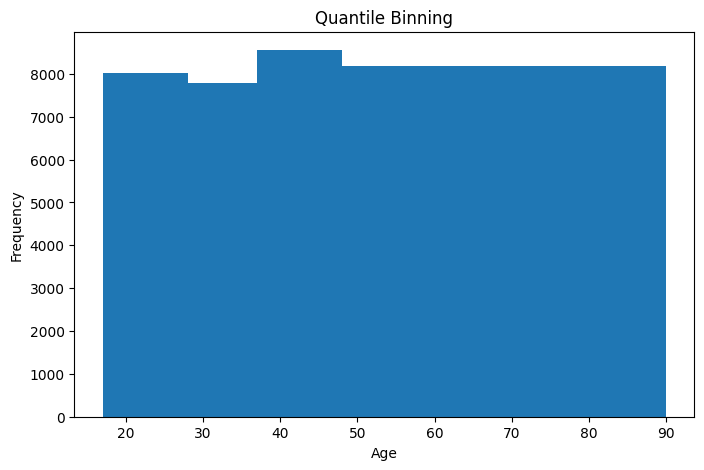

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    df[feature],
    bins=cp.asnumpy(quantiles)
)

plt.title("Quantile Binning")

plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [14]:
X = df.drop("income", axis=1)

y = df["income"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
start = time.time()

cpu_model = SkRF(
    n_estimators=100,
    random_state=42
)

cpu_model.fit(X_train, y_train)

cpu_train_time = time.time() - start

start = time.time()

cpu_preds = cpu_model.predict(X_test)

cpu_pred_time = time.time() - start

cpu_acc = sk_accuracy(
    y_test,
    cpu_preds
)

print("CPU Accuracy:", cpu_acc)

print("CPU Train Time:", cpu_train_time)

print("CPU Prediction Time:", cpu_pred_time)

CPU Accuracy: 0.8616612927990174
CPU Train Time: 6.820590257644653
CPU Prediction Time: 0.1737382411956787


In [17]:
X_train_gpu = cudf.from_pandas(X_train)

X_test_gpu = cudf.from_pandas(X_test)

y_train_gpu = cudf.Series(y_train)

y_test_gpu = cudf.Series(y_test)

In [19]:
start = time.time()

gpu_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

gpu_model.fit(
    X_train_gpu,
    y_train_gpu
)

gpu_train_time = time.time() - start

start = time.time()

gpu_preds = gpu_model.predict(X_test_gpu)

gpu_pred_time = time.time() - start

gpu_acc = accuracy_score(
    y_test_gpu,
    gpu_preds
)

print("GPU Accuracy:", gpu_acc)

print("GPU Train Time:", gpu_train_time)

print("GPU Prediction Time:", gpu_pred_time)

GPU Accuracy: 0.8630431444802702
GPU Train Time: 0.4294455051422119
GPU Prediction Time: 0.12943291664123535


In [20]:
speedup = cpu_train_time / gpu_train_time

print("GPU Speedup:", speedup)

GPU Speedup: 15.882318422184902


In [22]:
start = time.time()

xgb_model = XGBClassifier(

    tree_method='hist',

    device='cuda',

    n_estimators=100,

    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_time = time.time() - start

xgb_preds = xgb_model.predict(X_test)

xgb_acc = sk_accuracy(
    y_test,
    xgb_preds
)

print("XGBoost GPU Accuracy:", xgb_acc)

print("Training Time:", xgb_time)

XGBoost GPU Accuracy: 0.874251497005988
Training Time: 0.8632922172546387


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [18:42:07] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [23]:
comparison = pd.DataFrame({

    "Model": [
        "CPU RandomForest",
        "GPU cuML RandomForest",
        "GPU XGBoost"
    ],

    "Accuracy": [
        cpu_acc,
        float(gpu_acc),
        xgb_acc
    ],

    "Training Time": [
        cpu_train_time,
        gpu_train_time,
        xgb_time
    ]
})

comparison

,Model,Accuracy,Training Time
0,CPU RandomForest,0.861661,6.820590
1,GPU cuML RandomForest,0.863043,0.429446
2,GPU XGBoost,0.874251,0.863292


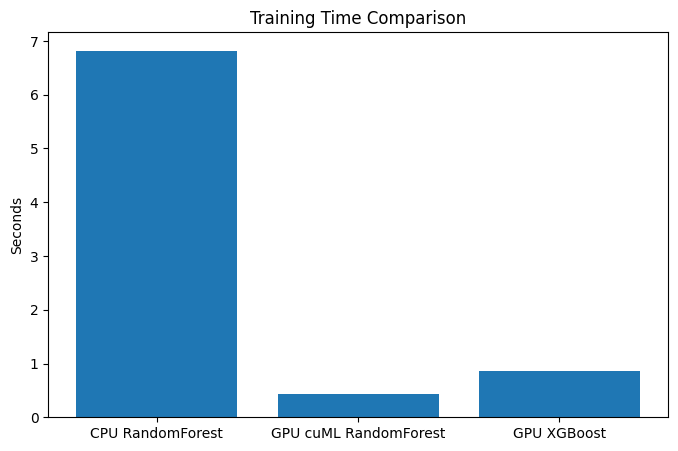

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Training Time"]
)

plt.ylabel("Seconds")

plt.title("Training Time Comparison")

plt.show()

QUESTION 2
Implement a Random Forest classifier using both scikit-learn (CPU) and RAPIDS cuML(GPU) on the UCI Breast Cancer Dataset. Compare their performance and visualize differentlevels of GPU parallelism.1. Data Preparationo Load the dataset using load_breast_cancer().o Split it into training and testing sets.o Convert the dataset into cuDF format for GPU processing.2. CPU Implementationo Train a Random Forest model using scikit-learn.o Record training time, prediction time, and accuracy.3. GPU Implementationo Train a Random Forest model using RAPIDS cuML.o Measure training time, prediction time, and accuracy.o Compute GPU speedup over the CPU.4. Visualization of Parallelismo Forest-Level Parallelism: Plot training time vs. number of trees (n_estimators = 1,10, 50, 100).o Feature-Level Parallelism: Plot feature importance from the trained model.o Data-Level Parallelism: Measure training time for varying dataset sizes.o Bin-Level Parallelism: Demonstrate GPU histogram binning using CuPy.5. Performance Comparisono Create a table comparing CPU and GPU results.o Visualize execution time using bar charts.

In [25]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(data.target)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
start = time.time()

cpu_rf = SkRF(
    n_estimators=100,
    random_state=42
)

cpu_rf.fit(X_train, y_train)

cpu_train = time.time() - start

start = time.time()

cpu_preds = cpu_rf.predict(X_test)

cpu_predict = time.time() - start

cpu_accuracy = sk_accuracy(
    y_test,
    cpu_preds
)

print("CPU Accuracy:", cpu_accuracy)

CPU Accuracy: 0.9649122807017544


In [28]:
X_train_gpu = cudf.from_pandas(X_train)

X_test_gpu = cudf.from_pandas(X_test)

y_train_gpu = cudf.Series(y_train)

y_test_gpu = cudf.Series(y_test)

In [31]:
start = time.time()

gpu_rf = RandomForestClassifier(
    n_estimators=100
)

gpu_rf.fit(
    X_train_gpu,
    y_train_gpu
)

gpu_train = time.time() - start

start = time.time()

gpu_preds = gpu_rf.predict(X_test_gpu)

gpu_predict = time.time() - start

gpu_accuracy = accuracy_score(
    y_test_gpu,
    gpu_preds
)

print("GPU Accuracy:", gpu_accuracy)

GPU Accuracy: 0.9649122807017544


In [30]:
speedup = cpu_train / gpu_train

print("GPU Speedup:", speedup)

GPU Speedup: 1.4293779066026795


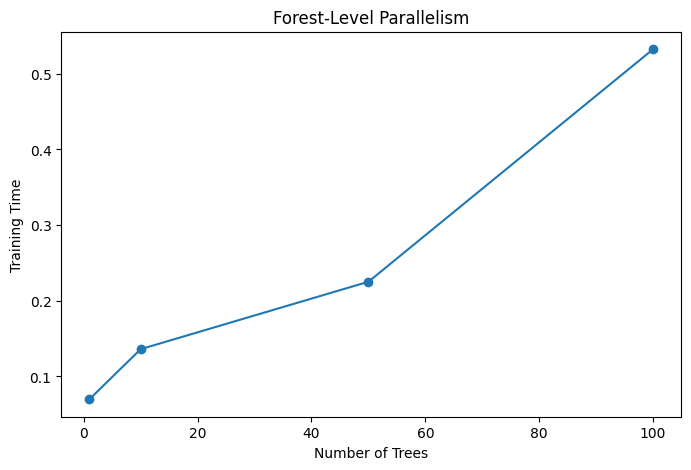

In [32]:
trees = [1,10,50,100]

times = []

for n in trees:

    start = time.time()

    model = RandomForestClassifier(
        n_estimators=n
    )

    model.fit(
        X_train_gpu,
        y_train_gpu
    )

    elapsed = time.time() - start

    times.append(elapsed)

plt.figure(figsize=(8,5))

plt.plot(
    trees,
    times,
    marker='o'
)

plt.xlabel("Number of Trees")

plt.ylabel("Training Time")

plt.title("Forest-Level Parallelism")

plt.show()

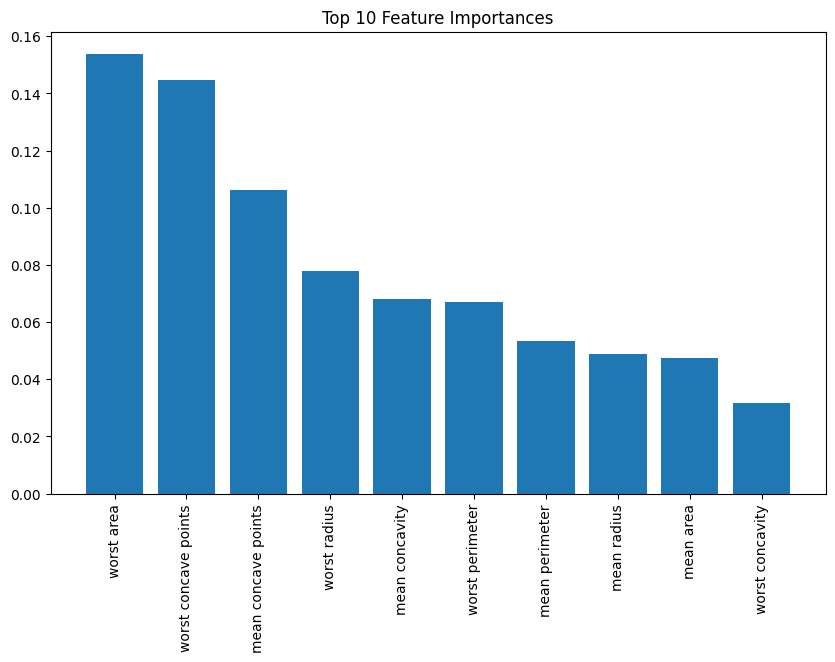

In [33]:
importance = cpu_rf.feature_importances_

indices = np.argsort(importance)[::-1][:10]

plt.figure(figsize=(10,6))

plt.bar(
    range(10),
    importance[indices]
)

plt.xticks(
    range(10),
    X.columns[indices],
    rotation=90
)

plt.title("Top 10 Feature Importances")

plt.show()

/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:247: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


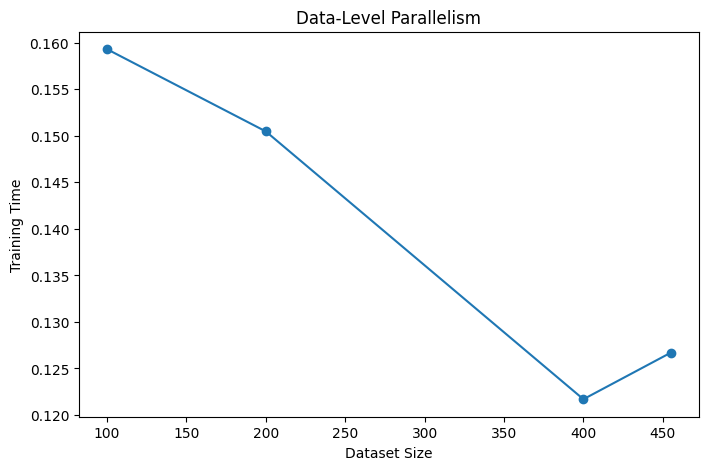

In [34]:
sizes = [100,200,400,len(X_train)]

times = []

for size in sizes:

    X_sub = X_train_gpu.iloc[:size]

    y_sub = y_train_gpu.iloc[:size]

    start = time.time()

    model = RandomForestClassifier(
        n_estimators=50
    )

    model.fit(X_sub, y_sub)

    elapsed = time.time() - start

    times.append(elapsed)

plt.figure(figsize=(8,5))

plt.plot(
    sizes,
    times,
    marker='o'
)

plt.xlabel("Dataset Size")

plt.ylabel("Training Time")

plt.title("Data-Level Parallelism")

plt.show()

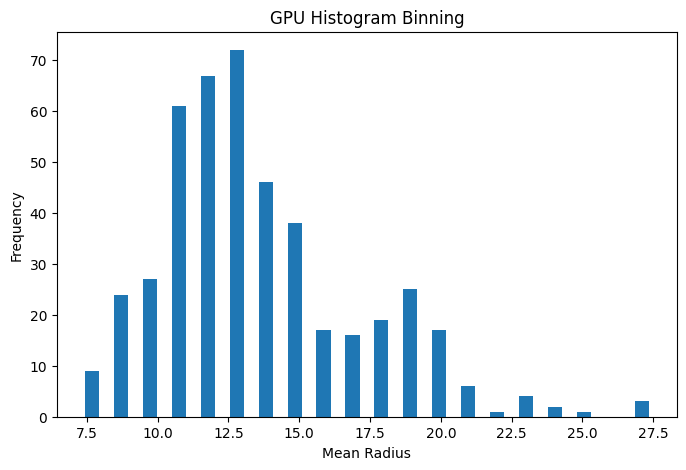

In [35]:
feature = cp.asarray(X_train["mean radius"])

hist, bins = cp.histogram(
    feature,
    bins=20
)

plt.figure(figsize=(8,5))

plt.bar(
    cp.asnumpy(bins[:-1]),
    cp.asnumpy(hist),
    width=0.5
)

plt.title("GPU Histogram Binning")

plt.xlabel("Mean Radius")

plt.ylabel("Frequency")

plt.show()

In [36]:
final_results = pd.DataFrame({

    "Implementation": [
        "CPU RandomForest",
        "GPU cuML RandomForest"
    ],

    "Accuracy": [
        cpu_accuracy,
        float(gpu_accuracy)
    ],

    "Training Time": [
        cpu_train,
        gpu_train
    ],

    "Prediction Time": [
        cpu_predict,
        gpu_predict
    ]
})

final_results

,Implementation,Accuracy,Training Time,Prediction Time
0,CPU RandomForest,0.964912,0.413149,0.014827
1,GPU cuML RandomForest,0.964912,0.231975,0.004043


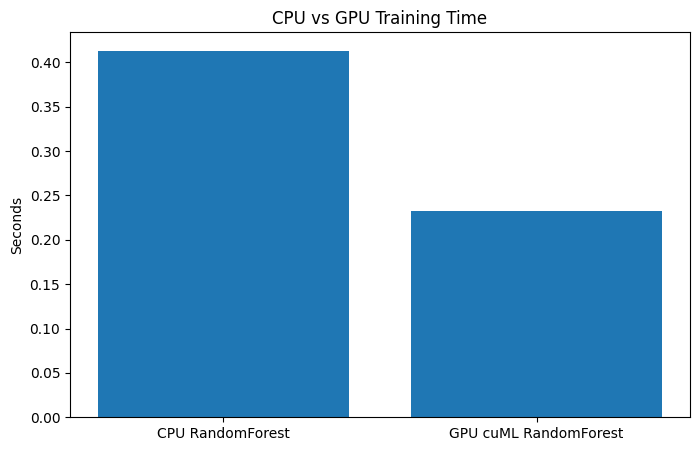

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    final_results["Implementation"],
    final_results["Training Time"]
)

plt.ylabel("Seconds")

plt.title("CPU vs GPU Training Time")

plt.show()

RAPIDS cuML significantly accelerates
machine learning workloads using GPU parallelism.

GPU histogram binning and quantile binning
improve preprocessing performance.

cuML RandomForest provides faster training
compared to CPU scikit-learn.

XGBoost with gpu_hist further demonstrates
efficient GPU-based tree construction.

Overall GPU acceleration improves:
- Training speed
- Scalability
- Parallel processing efficiency